# Single Document Processing

Full template-driven checkbox and OCR pipeline for processing a single document.

In [11]:
from pathlib import Path
import sys

# Find project root by looking for src/ directory
project_root = Path.cwd()
while not (project_root / 'src').exists() and project_root.parent != project_root:
    project_root = project_root.parent

sys.path.insert(0, str(project_root))

# Define path constants
DATA_DIR = project_root / 'data'
TEMPLATES_DIR = DATA_DIR / 'templates'
INPUTS_DIR = DATA_DIR / 'inputs'
OUTPUTS_DIR = project_root / 'outputs'
VISUALIZATIONS_DIR = OUTPUTS_DIR / 'visualizations'
PROCESSED_DIR = OUTPUTS_DIR / 'processed'
REPORTS_DIR = OUTPUTS_DIR / 'reports'

import os
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
from src.alignment.phase_1_alignment import FeatureBasedAligner, AlignmentConfig
from src.visualization.diff_visualization import create_red_overlay_diff
from src.ocr.debug_utils import debug_slice_ocr, build_paddle_ocr_debugger
from src.ocr.ocr_extraction import (
    FastOCRExtractor,
    visualize_extractions,
    extract_roi,
    preprocess_roi,
)
from src.template import (
    load_zones_from_template,
    build_union_mask,
    apply_mask,
    extract_polygon_roi,
    detect_checkboxes_from_template_image,
    ROI_PADDING,
    DET_DB_THRESH,
    DET_DB_BOX_THRESH,
    DET_DB_UNCLIP_RATIO,
    DET_LIMIT_SIDE_LEN,
    DET_LIMIT_TYPE,
    USE_DOC_ORIENTATION_CLASSIFY,
    USE_DOC_UNWARPING,
    USE_TEXTLINE_ORIENTATION,
)

## Configuration

In [12]:
# Template and input paths
TEMPLATE_PATH = str(TEMPLATES_DIR / "template.json")
TEMPLATE_IMAGE_PATH = str(TEMPLATES_DIR / "template.jpg")
INPUT_IMAGE_PATH = str(INPUTS_DIR / "input_document.jpg")

# Output paths
OUTPUT_JSON_PATH = str(PROCESSED_DIR / "extracted_data.json")
SLICE_DEBUG_DIR = str(REPORTS_DIR / "debug_slices")
SLICE_LOG_PATH = str(REPORTS_DIR / "debug_slices" / "slice_debug_log.txt")
SAVE_SLICE_DEBUG = True

## Step 1: Load Images and Align

[INFO] Using ORB detector (Oriented FAST and Rotated BRIEF)
       Pros: 24x faster than SIFT, free license, efficient
       Cons: Less robust to extreme rotations (>45°)

PHASE 1: GLOBAL FEATURE-BASED REGISTRATION

[STEP 1.1] Feature Detection and Matching
[INFO] Detected 5000 keypoints
[INFO] Detected 5000 keypoints
[INFO] Found 1002/5000 good matches (20.0%)

[STEP 1.2] Homography Computation (RANSAC)
[INFO] RANSAC found 783/1002 inliers (78.1%)
[INFO] Mean reprojection error: 1.73 pixels

[STEP 1.3] Image Warping and Registration
[INFO] Warped input image to template size: 2610x3348

----------------------------------------------------------------------
ALIGNMENT QUALITY METRICS:
----------------------------------------------------------------------
  ✓ Inlier ratio: 78.1% (target: >40%)
  ✓ Reprojection error: 1.73px (target: <5px)
  ✓ Total matches: 1002
  ✓ Inlier matches: 783

  Quality Checks:
    ✓ Sufficient matches: PASS
    ✓ Good inlier ratio: PASS
    ✓ Low reprojection

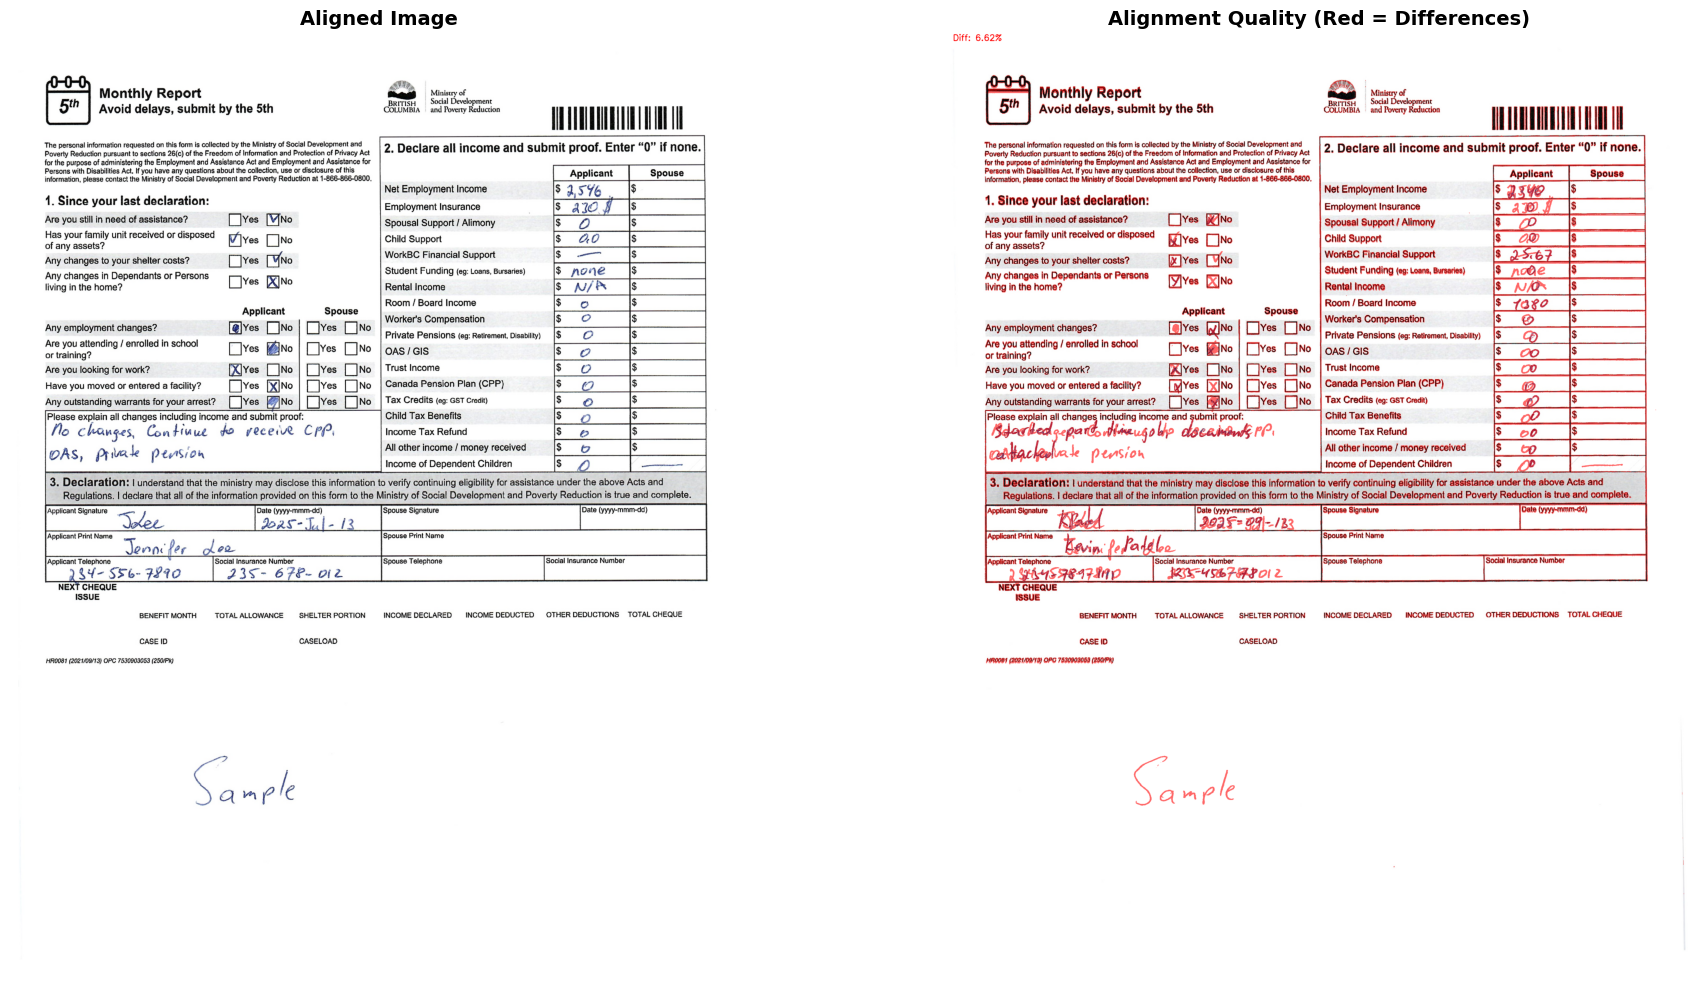

In [13]:
# Load images
template = cv2.imread(TEMPLATE_IMAGE_PATH)
input_img = cv2.imread(INPUT_IMAGE_PATH)

# Configure and align
config = AlignmentConfig(
    feature_detector="ORB",
    max_features=5000,
    ratio_test_threshold=0.7,
    ransac_threshold=5.0,
    min_matches=10,
    verbose=True,
)

aligner = FeatureBasedAligner(config)
result = aligner.align(input_img, template)

# Save alignment outputs
VISUALIZATIONS_DIR.mkdir(parents=True, exist_ok=True)
cv2.imwrite(str(VISUALIZATIONS_DIR / "aligned_default_orb.jpg"), result.aligned_image)

red_overlay = create_red_overlay_diff(template, result.aligned_image, threshold=30, alpha=0.6)
cv2.imwrite(str(VISUALIZATIONS_DIR / "aligned_default_orb_red_overlay.jpg"), red_overlay)

print(f"[DEFAULT] Error: {result.reprojection_error:.2f}px, Inliers: {result.inlier_ratio:.1f}%")

# Display alignment results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(cv2.cvtColor(result.aligned_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Aligned Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(red_overlay, cv2.COLOR_BGR2RGB))
axes[1].set_title('Alignment Quality (Red = Differences)', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Step 2: Load Template Zones

In [14]:
# Load zones (polygons + rectangles) and checkbox boxes from template.json
polygon_zones, rectangle_zones, checkbox_boxes = load_zones_from_template(TEMPLATE_PATH)

print(
    f"\n[TEMPLATE] Loaded {len(polygon_zones)} polygon text zones, "
    f"{len(rectangle_zones)} rectangle text zones, "
    f"{len(checkbox_boxes)} checkbox boxes"
)


[TEMPLATE] Loaded 11 polygon text zones, 36 rectangle text zones, 28 checkbox boxes


## Step 3: Build Mask and Detect Checkboxes

In [15]:
# Build and apply global mask for OCR (white everywhere, keep text zones)
union_mask = build_union_mask(result.aligned_image.shape, polygon_zones, rectangle_zones)
masked_image = apply_mask(result.aligned_image, union_mask)

# Save masked visualization
cv2.imwrite(str(VISUALIZATIONS_DIR / "aligned_masked_for_ocr.png"), masked_image)

# Detect checkboxes from template-defined boxes
checkbox_results = detect_checkboxes_from_template_image(
    image=result.aligned_image,
    checkbox_boxes=checkbox_boxes,
    checked_threshold=0.15,  # Adjust if needed (0.10-0.25 typical)
    verbose=True,
)

# Print checkbox results
print("[CHECKBOX] Results:")
for name, data in checkbox_results.items():
    icon = "☑" if data["checked"] else "☐"
    conf_icon = "✓" if data["confidence"] > 0.5 else "⚠"
    print(f"  {icon} {name:30s}: {data['checked']} (conf: {data['confidence']:.2f}) {conf_icon}")


[CHECKBOX] Processing 28 checkbox fields from template.json

[CHECKBOX] 'checkbox_need_assistance_yes'
      ✓ CHECKED (density: 0.270, conf: 0.90)

[CHECKBOX] 'checkbox_need_assistance_no'
      ✓ CHECKED (density: 0.383, conf: 1.00)

[CHECKBOX] 'checkbox_family_assets_yes'
      ✓ CHECKED (density: 0.333, conf: 1.00)

[CHECKBOX] 'checkbox_family_assets_no'
      ✓ CHECKED (density: 0.192, conf: 0.64)

[CHECKBOX] 'checkbox_shelter_yes'
      ✓ CHECKED (density: 0.207, conf: 0.69)

[CHECKBOX] 'checkbox_shelter_no'
      ✓ CHECKED (density: 0.267, conf: 0.89)

[CHECKBOX] 'checkbox_dependants_yes'
      ✓ CHECKED (density: 0.206, conf: 0.69)

[CHECKBOX] 'checkbox_dependants_no'
      ✓ CHECKED (density: 0.410, conf: 1.00)

[CHECKBOX] 'checkbox_employment_changes_yes'
      ✓ CHECKED (density: 0.496, conf: 1.00)

[CHECKBOX] 'checkbox_employment_changes_no'
      ✓ CHECKED (density: 0.266, conf: 0.89)

[CHECKBOX] 'checkbox_employment_changes_spouse_yes'
      ✓ CHECKED (density: 0.254, co

## Step 4: Initialize OCR Extractor

In [16]:
# Initialize FAST OCR extractor
extractor = FastOCRExtractor(
    lang="en",
    verbose=True,
    use_doc_orientation_classify=USE_DOC_ORIENTATION_CLASSIFY,
    use_doc_unwarping=USE_DOC_UNWARPING,
    use_textline_orientation=USE_TEXTLINE_ORIENTATION,
    det_db_thresh=DET_DB_THRESH,
    det_db_box_thresh=DET_DB_BOX_THRESH,
    det_db_unclip_ratio=DET_DB_UNCLIP_RATIO,
    det_limit_side_len=DET_LIMIT_SIDE_LEN,
    det_limit_type=DET_LIMIT_TYPE,
)

# Setup debug utilities
os.makedirs(SLICE_DEBUG_DIR, exist_ok=True)
slice_debugger = None
if SAVE_SLICE_DEBUG:
    slice_debugger = build_paddle_ocr_debugger(
        lang="en",
        det_limit_side_len=DET_LIMIT_SIDE_LEN,
        det_limit_type=DET_LIMIT_TYPE,
        det_db_thresh=DET_DB_THRESH,
        det_db_box_thresh=DET_DB_BOX_THRESH,
        det_db_unclip_ratio=DET_DB_UNCLIP_RATIO,
        use_doc_orientation_classify=USE_DOC_ORIENTATION_CLASSIFY,
        use_doc_unwarping=USE_DOC_UNWARPING,
        use_textline_orientation=USE_TEXTLINE_ORIENTATION,
    )

Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/lex/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.


[OCR] Initializing PaddleOCR...
      Language: en


Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/lex/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/lex/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/lex/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/lex/.paddlex/official_models/PP-OCRv5_server_det`.


[OCR] Ready!


Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/lex/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.


## Step 5: Extract Text from Polygon Zones

In [17]:
extracted_data = {}

# Polygon text zones
print(f"\n[OCR] Extracting {len(polygon_zones)} polygon text fields (padding: {ROI_PADDING}px)")
for zone in polygon_zones:
    roi = extract_polygon_roi(masked_image, zone["polygon"], padding=ROI_PADDING)
    text, confidence = extractor.extract_text(roi, preprocess=True)
    extracted_data[zone["name"]] = {
        "text": text,
        "confidence": confidence,
        "bbox": zone["bbox"] if zone.get("bbox") else None,
    }
    cv2.imwrite(f"{SLICE_DEBUG_DIR}/{zone['name']}_roi.jpg", roi)
    processed_roi = preprocess_roi(roi)
    cv2.imwrite(f"{SLICE_DEBUG_DIR}/{zone['name']}_processed.jpg", processed_roi)
    conf_icon = "✓" if confidence > 0.5 else "⚠"
    print(f"  {conf_icon} {zone['name']:25s}: '{text}' (conf: {confidence:.2f})")
    if SAVE_SLICE_DEBUG and slice_debugger is not None:
        debug_slice_ocr(
            processed_roi,
            slice_debugger,
            SLICE_DEBUG_DIR,
            f"{zone['name']}_processed",
            log_path=SLICE_LOG_PATH,
        )


[OCR] Extracting 11 polygon text fields (padding: 15px)
[DEBUG] About to call self.ocr.ocr() on image shape (116, 1214, 3)
[DEBUG] OCR call completed successfully
[DEBUG] Parsed OCR texts: ['Jennifer dee']
[DEBUG] Parsed OCR confidences: [0.8890891075134277]
[DEBUG] OCR detected 1 text regions:
         'Jennifer dee' (conf: 0.89)
  ✓ name                     : 'Jennifer dee' (conf: 0.89)
[DEBUG] About to call self.ocr.ocr() on image shape (258, 1214, 3)
[DEBUG] OCR call completed successfully
[DEBUG] Parsed OCR texts: ['No changes, Continne to receive Cpp.', 'OAS, Private pension']
[DEBUG] Parsed OCR confidences: [0.9059923887252808, 0.8655932545661926]
[DEBUG] OCR detected 2 text regions:
         'No changes, Continne to receive Cpp.' (conf: 0.91)
         'OAS, Private pension' (conf: 0.87)
  ✓ explain_changes          : 'No changes, Continne to receive Cpp. OAS, Private pension' (conf: 0.89)
[DEBUG] About to call self.ocr.ocr() on image shape (115, 767, 3)
[DEBUG] OCR call comple

## Step 6: Extract Text from Rectangle Zones

In [18]:
# Rectangle text zones
print(f"\n[OCR] Extracting {len(rectangle_zones)} rectangle text fields (padding: {ROI_PADDING}px)")
for zone in rectangle_zones:
    roi = extract_roi(masked_image, zone["bbox"], padding=ROI_PADDING)
    text, confidence = extractor.extract_text(roi, preprocess=True)
    extracted_data[zone["name"]] = {
        "text": text,
        "confidence": confidence,
        "bbox": zone["bbox"],
    }
    cv2.imwrite(f"{SLICE_DEBUG_DIR}/{zone['name']}_roi.jpg", roi)
    processed_roi = preprocess_roi(roi)
    cv2.imwrite(f"{SLICE_DEBUG_DIR}/{zone['name']}_processed.jpg", processed_roi)
    conf_icon = "✓" if confidence > 0.5 else "⚠"
    print(f"  {conf_icon} {zone['name']:25s}: '{text}' (conf: {confidence:.2f})")
    if SAVE_SLICE_DEBUG and slice_debugger is not None:
        debug_slice_ocr(
            processed_roi,
            slice_debugger,
            SLICE_DEBUG_DIR,
            f"{zone['name']}_processed",
            log_path=SLICE_LOG_PATH,
        )


[OCR] Extracting 36 rectangle text fields (padding: 15px)
[DEBUG] About to call self.ocr.ocr() on image shape (92, 270, 3)
[DEBUG] OCR call completed successfully
[DEBUG] Parsed OCR texts: ['2,546']
[DEBUG] Parsed OCR confidences: [0.9172922372817993]
[DEBUG] OCR detected 1 text regions:
         '2,546' (conf: 0.92)
  ✓ income1                  : '2,546' (conf: 0.92)
[DEBUG] About to call self.ocr.ocr() on image shape (85, 264, 3)
[DEBUG] OCR call completed successfully
[DEBUG] Parsed OCR texts: ['d30']
[DEBUG] Parsed OCR confidences: [0.8030229210853577]
[DEBUG] OCR detected 1 text regions:
         'd30' (conf: 0.80)
  ✓ income2                  : 'd30' (conf: 0.80)
[DEBUG] About to call self.ocr.ocr() on image shape (88, 264, 3)
[DEBUG] OCR call completed successfully
[DEBUG] Parsed OCR texts: ['6', '0']
[DEBUG] Parsed OCR confidences: [0.15917684137821198, 0.8400816917419434]
[DEBUG] OCR detected 2 text regions:
         '6' (conf: 0.16)
         '0' (conf: 0.84)
  ⚠ income3     

## Step 7: Save Results

[VIS] Saved extraction visualization to: /home/lex/GitHub/ai-adoption-research-and-development/Template-alignment/outputs/visualizations/extraction_visualization.jpg

[DONE] Saved to: /home/lex/GitHub/ai-adoption-research-and-development/Template-alignment/outputs/processed/extracted_data.json


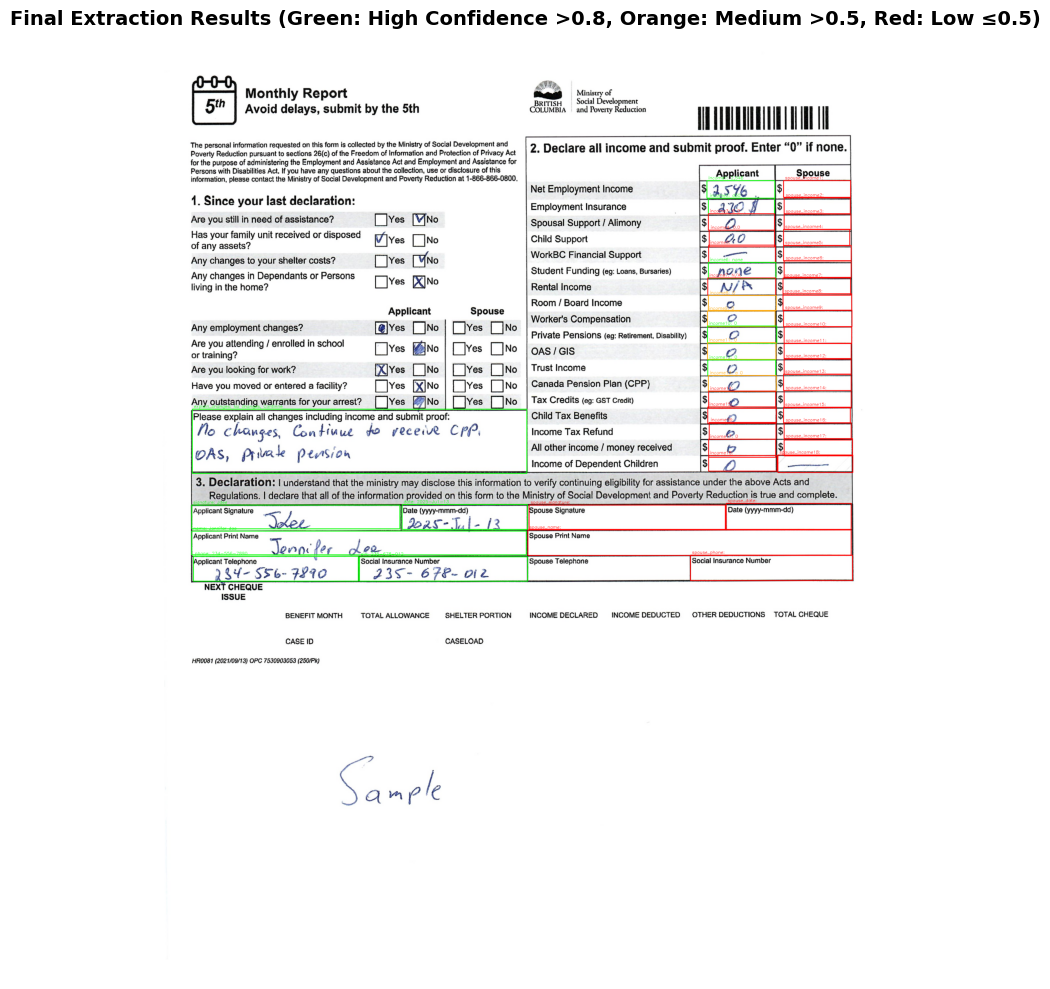

In [19]:
# Combine with checkbox results
combined_output = {**extracted_data, **checkbox_results}

# Save combined JSON
os.makedirs(os.path.dirname(OUTPUT_JSON_PATH), exist_ok=True)
with open(OUTPUT_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(combined_output, f, indent=2, ensure_ascii=False)

# Visualize OCR extractions
extraction_vis = visualize_extractions(result.aligned_image, extracted_data, str(VISUALIZATIONS_DIR / "extraction_visualization.jpg"))

print(f"\n[DONE] Saved to: {OUTPUT_JSON_PATH}")

# Display final extraction visualization
plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(extraction_vis, cv2.COLOR_BGR2RGB))
plt.title('Final Extraction Results (Green: High Confidence >0.8, Orange: Medium >0.5, Red: Low ≤0.5)', 
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## Step 8: Combined Summary Visualization

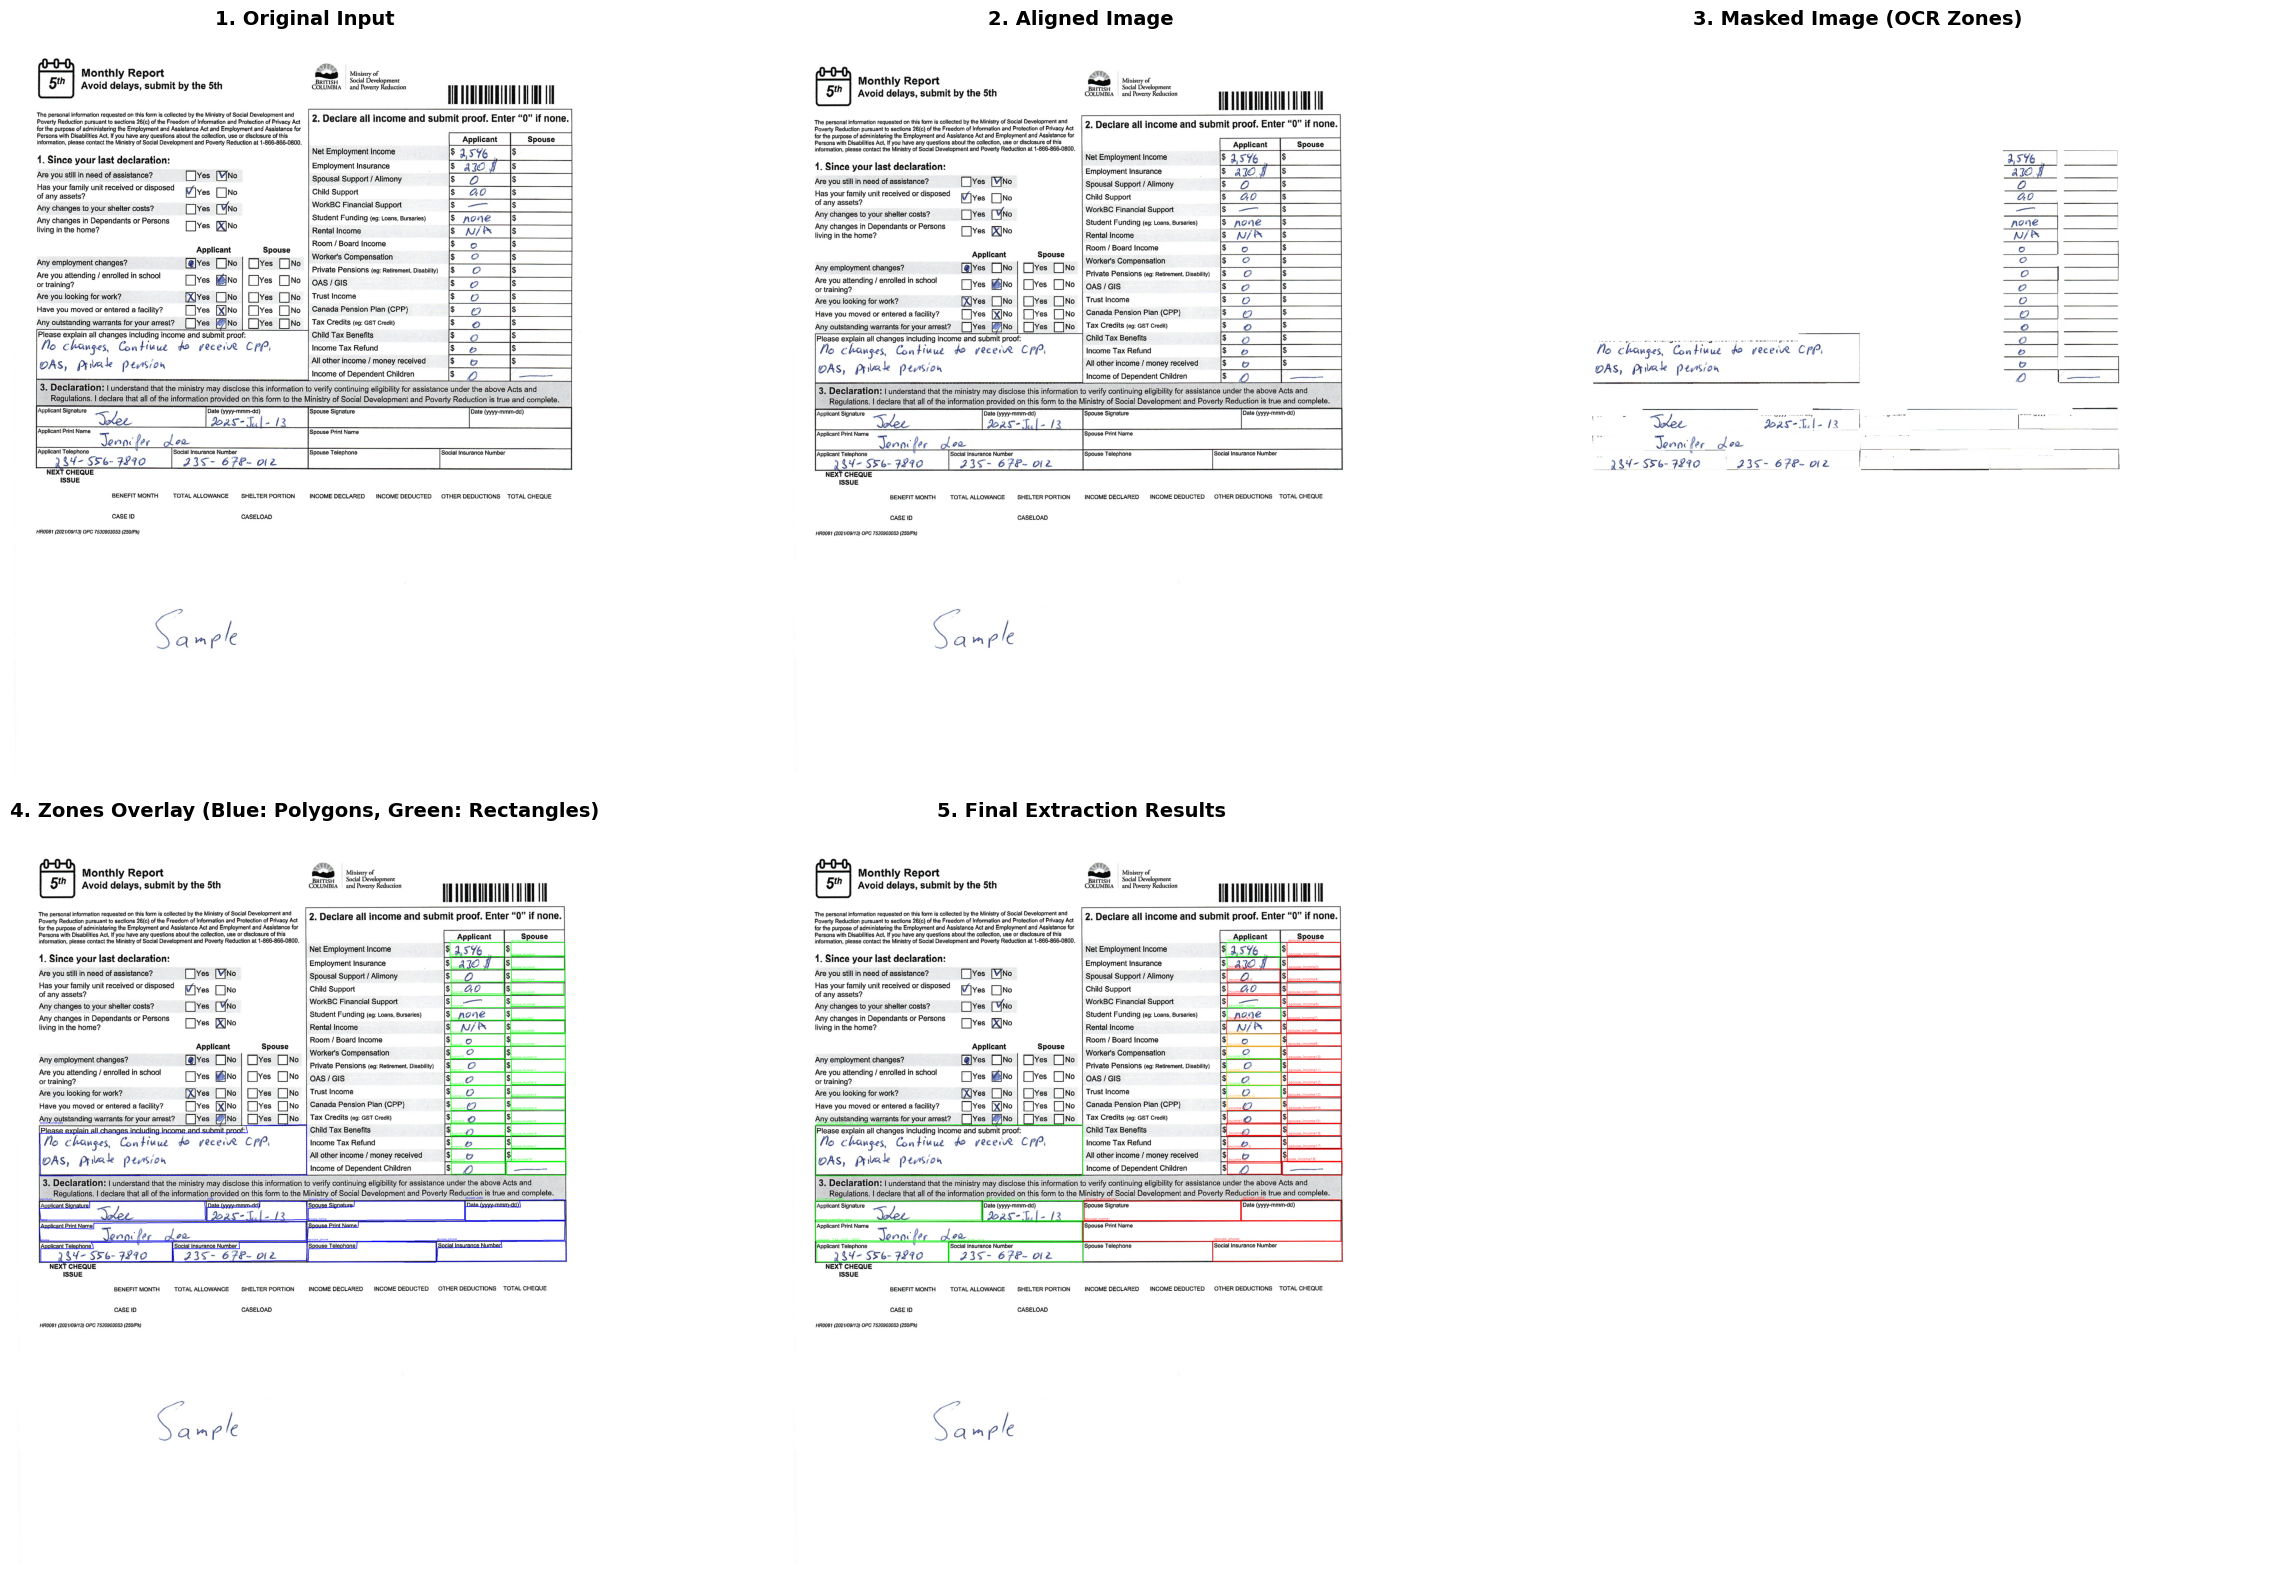

In [20]:
# Create zones overlay visualization
zones_overlay = result.aligned_image.copy()

# Draw polygon zones in blue
for zone in polygon_zones:
    poly = np.array(zone["polygon"], dtype=np.int32)
    cv2.polylines(zones_overlay, [poly], isClosed=True, color=(255, 0, 0), thickness=2)
    # Add label if bbox available
    if zone.get("bbox"):
        bbox = zone["bbox"]
        cv2.putText(zones_overlay, zone["name"], (bbox["x"], bbox["y"] - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)

# Draw rectangle zones in green
for zone in rectangle_zones:
    bbox = zone["bbox"]
    x, y, w, h = bbox["x"], bbox["y"], bbox["width"], bbox["height"]
    cv2.rectangle(zones_overlay, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(zones_overlay, zone["name"], (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

# Create combined summary visualization with 5 panels
fig, axes = plt.subplots(2, 3, figsize=(24, 16))

# Panel 1: Original input
axes[0, 0].imshow(cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('1. Original Input', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

# Panel 2: Aligned image
axes[0, 1].imshow(cv2.cvtColor(result.aligned_image, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('2. Aligned Image', fontsize=14, fontweight='bold')
axes[0, 1].axis('off')

# Panel 3: Masked image
axes[0, 2].imshow(cv2.cvtColor(masked_image, cv2.COLOR_BGR2RGB))
axes[0, 2].set_title('3. Masked Image (OCR Zones)', fontsize=14, fontweight='bold')
axes[0, 2].axis('off')

# Panel 4: Zones overlay
axes[1, 0].imshow(cv2.cvtColor(zones_overlay, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('4. Zones Overlay (Blue: Polygons, Green: Rectangles)', fontsize=14, fontweight='bold')
axes[1, 0].axis('off')

# Panel 5: Final extraction results
axes[1, 1].imshow(cv2.cvtColor(extraction_vis, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('5. Final Extraction Results', fontsize=14, fontweight='bold')
axes[1, 1].axis('off')

# Hide the 6th subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()